<a href="https://colab.research.google.com/github/HamzaEric/RNN_Human_Activity_Recognition/blob/main/Notebooks/Hidden_states_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
def load_csv_dataset(train_path="/content/drive/MyDrive/HAR_Processed_Data/har_train_standardized.csv",
                     test_path="/content/drive/MyDrive/HAR_Processed_Data/har_test_standardized.csv",
                     timesteps=128, channels=9):
    train_df = pd.read_csv(train_path)
    test_df  = pd.read_csv(test_path)

    def df_to_arrays(df):
        y = df["label"].values.astype(np.int64)              # (N,)
        subj = df["subject"].values.astype(np.int64)         # (N,)
        X_flat = df.drop(columns=["label","subject"]).values # (N, 1152)
        X = X_flat.reshape(len(df), timesteps, channels)     # (N, 128, 9)
        return X.astype(np.float32), y, subj

    X_train, y_train, subj_train = df_to_arrays(train_df)
    X_test,  y_test,  subj_test  = df_to_arrays(test_df)

    return X_train, y_train, X_test, y_test, subj_train, subj_test


X_train, y_train, X_test, y_test, subj_train, subj_test = load_csv_dataset()

# Wrap as PyTorch tensors (batch-first: (B, 128, 9))
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

BATCH_SIZE = 96
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t), batch_size=BATCH_SIZE, shuffle=False)

print("Loaded from CSV →",
      "X_train", X_train_t.shape, "| y_train", y_train_t.shape,
      "| X_test", X_test_t.shape,  "| y_test",  y_test_t.shape)

Loaded from CSV → X_train torch.Size([7352, 128, 9]) | y_train torch.Size([7352]) | X_test torch.Size([2947, 128, 9]) | y_test torch.Size([2947])


In [3]:
# # NPY loader (optional path)

# def load_npy_dataset(
#     x_train_path="X_train_std.npy",
#     y_train_path="y_train.npy",
#     x_test_path="X_test_std.npy",
#     y_test_path="y_test.npy"
# ):
#     X_train = np.load(x_train_path)  # (N, 128, 9)
#     y_train = np.load(y_train_path)
#     X_test  = np.load(x_test_path)
#     y_test  = np.load(y_test_path)
#     return X_train, y_train, X_test, y_test

# # Example usage (commented out by default):
# # X_train, y_train, X_test, y_test = load_npy_dataset()
# # X_train_t = torch.tensor(X_train, dtype=torch.float32)
# # y_train_t = torch.tensor(y_train, dtype=torch.long)
# # X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
# # y_test_t  = torch.tensor(y_test,  dtype=torch.long)
# # train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
# # test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t), batch_size=64, shuffle=False)
# # print("Loaded from NPY →", X_train_t.shape, y_train_t.shape, X_test_t.shape, y_test_t.shape)

In [5]:
class RNNClassifier(nn.Module):
    def __init__(self, input_size=9, hidden_size=32, num_classes=6, num_layers=1, nonlinearity="tanh"):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            nonlinearity=nonlinearity,
            batch_first=True,   # (batch, seq, input)
            bidirectional=False
        )
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        """
        x: (batch, seq_len, input_size)
        returns:
          logits: (batch, num_classes)
          out_seq: (batch, seq_len, hidden_size)  # all hidden states
          h_n: (num_layers, batch, hidden_size)   # final hidden state(s)
        """
        out_seq, h_n = self.rnn(x)
        last_hidden = out_seq[:, -1, :]    # (batch, hidden)
        logits = self.fc(last_hidden)      # (batch, classes)
        return logits, out_seq, h_n


In [6]:
model = RNNClassifier(input_size=9, hidden_size=32, num_classes=6, num_layers=1, nonlinearity="tanh")

ckpt_path = "rnn_har.pth"
state = torch.load(ckpt_path, map_location="cpu", weights_only=False)
model.load_state_dict(state)
model.eval()

print("Loaded trained weights from:", ckpt_path)

Loaded trained weights from: rnn_har.pth


In [9]:
xb, yb = next(iter(test_loader))   # or train_loader
logits, out_seq, h_n = model(xb)

print("xb shape      :", tuple(xb.shape))       # (B, 128, 9)
print("out_seq shape :", tuple(out_seq.shape))  # (B, 128, H)
print("h_n shape     :", tuple(h_n.shape))      # (1, B, H)
print("logits shape  :", tuple(logits.shape))   # (B, 6)

probs = F.softmax(logits, dim=1)
print("First row prob sum ~1.0:", float(probs[0].sum()))


xb shape      : (96, 128, 9)
out_seq shape : (96, 128, 32)
h_n shape     : (1, 96, 32)
logits shape  : (96, 6)
First row prob sum ~1.0: 1.0


/tmp/ipykernel_3876/1045506889.py:10: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print("First row prob sum ~1.0:", float(probs[0].sum()))


### **Extract Hidden States**

**Theory — What are hidden states?**

When we pass a sequence through an RNN:

- Each timestep $t$ produces a **hidden state** $h_t$.  
- With `hidden_size = 32`, each $h_t$ is a 32-dimensional vector:
  $$
  h_t = \big[h_t^{(1)}, h_t^{(2)}, \dots, h_t^{(32)}\big].
  $$
- Over 128 timesteps, the model produces 128 such vectors:
  $$
  (h_1, h_2, \dots, h_{128}), \quad h_t \in \mathbb{R}^{32}.
  $$

This gives us a **temporal trajectory** in a 32-dimensional space.

**What the RNN actually outputs**

For a batch of $B$ sequences, the forward pass returns:

- **`out_seq`**: all hidden states across time, shape $= (B, 128, H)$  
  (here $B=96$, $H=32$).
- **`h_n`**: the final hidden state(s), shape $= (1, B, H)$.
- **`logits`**: class scores after the FC layer, shape $= (B, 6)$.

So, the RNN is really doing two jobs:
1) Building a **memory trajectory** $h_1 \dots h_{128}$.  
2) Passing the **last hidden state** into a classifier.


In [10]:
ACTIVITY_MAP = {
    0: "WALKING",
    1: "WALKING_UPSTAIRS",
    2: "WALKING_DOWNSTAIRS",
    3: "SITTING",
    4: "STANDING",
    5: "LAYING",
}

def first_index_of_label(y_batch: torch.Tensor, label_idx: int):
    """Return first index in y_batch == label_idx, or None if not found."""
    y_np = y_batch.cpu().numpy()
    hits = np.where(y_np == label_idx)[0]
    return int(hits[0]) if hits.size > 0 else None

def pick_topk_dims_by_variance(hidden_seq: np.ndarray, k: int = 3):
    """Pick top-k hidden dimensions with highest variance across time."""
    var = hidden_seq.var(axis=0)  # (H,)
    return np.argsort(var)[::-1][:k]

def plot_hidden_dims_over_time(hidden_seq: np.ndarray, dims, title: str):
    """Plot selected hidden dims across timesteps."""
    T = hidden_seq.shape[0]
    t = np.arange(1, T+1)
    plt.figure(figsize=(10,4))
    for d in dims:
        plt.plot(t, hidden_seq[:, d], label=f"h[t, dim={d}]")
    plt.xlabel("Timestep (t)")
    plt.ylabel("Hidden value")
    plt.title(title)
    plt.legend()
    plt.show()

def plot_hidden_norm_over_time(hidden_seq: np.ndarray, title: str):
    """Plot the L2 norm of hidden vector across timesteps."""
    norms = np.linalg.norm(hidden_seq, axis=1)
    t = np.arange(1, hidden_seq.shape[0]+1)
    plt.figure(figsize=(10,3))
    plt.plot(t, norms)
    plt.xlabel("Timestep (t)")
    plt.ylabel("||h_t||_2")
    plt.title(title)
    plt.show()

Batch size B=96, seq_len T=128, hidden_size H=32
Visualizing sample index 31, true label = SITTING


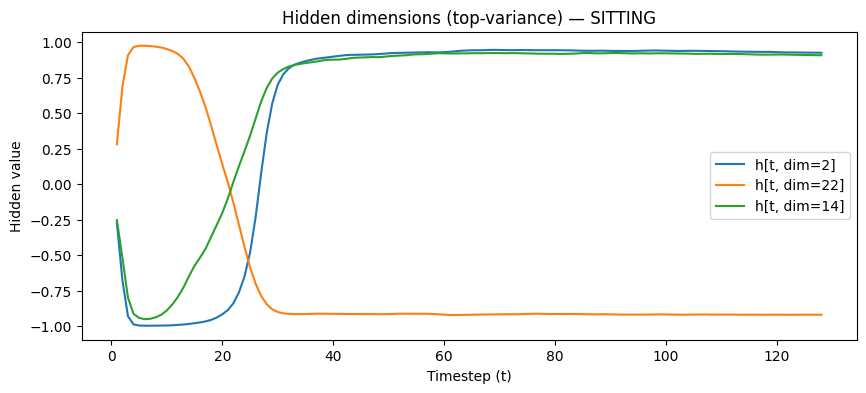

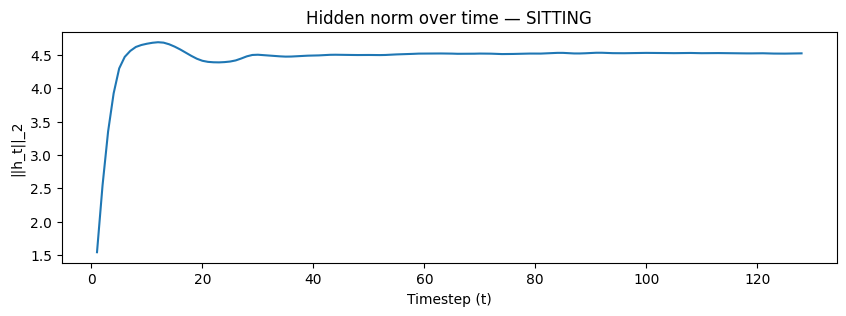

In [13]:
xb, yb = next(iter(test_loader))   # xb: (96,128,9), yb: (96,)

model.eval()
with torch.no_grad():
    logits, out_seq, h_n = model(xb)  # out_seq: (96,128,32)

B, T, H = out_seq.shape
print(f"Batch size B={B}, seq_len T={T}, hidden_size H={H}")

# Pick a sample with label = SITTING (class=3); fallback = first sample
target_label = 3
idx = first_index_of_label(yb, target_label)
if idx is None:
    idx = 0
    target_label = int(yb[idx])

print(f"Visualizing sample index {idx}, true label = {ACTIVITY_MAP[int(target_label)]}")

# Hidden states for that sample → (128,32)
hidden_seq = out_seq[idx].cpu().numpy()

# Strategy 1: top-variance dims
topk_dims = pick_topk_dims_by_variance(hidden_seq, k=3)
plot_hidden_dims_over_time(
    hidden_seq, topk_dims,
    title=f"Hidden dimensions (top-variance) — {ACTIVITY_MAP[int(target_label)]}"
)

# Strategy 2: hidden norm
plot_hidden_norm_over_time(
    hidden_seq,
    title=f"Hidden norm over time — {ACTIVITY_MAP[int(target_label)]}"
)

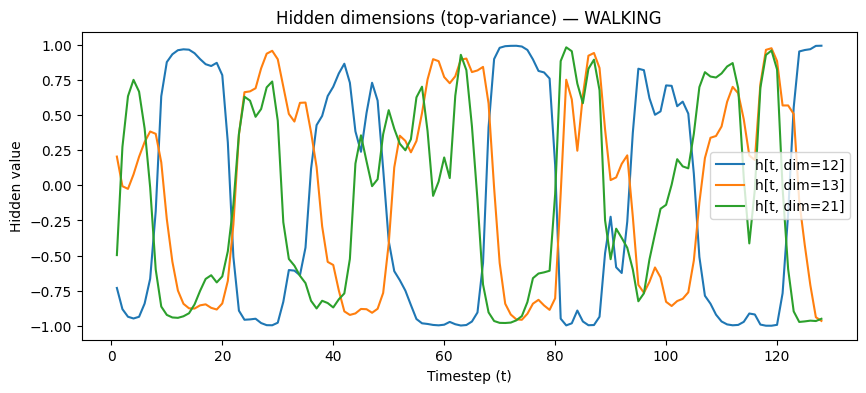

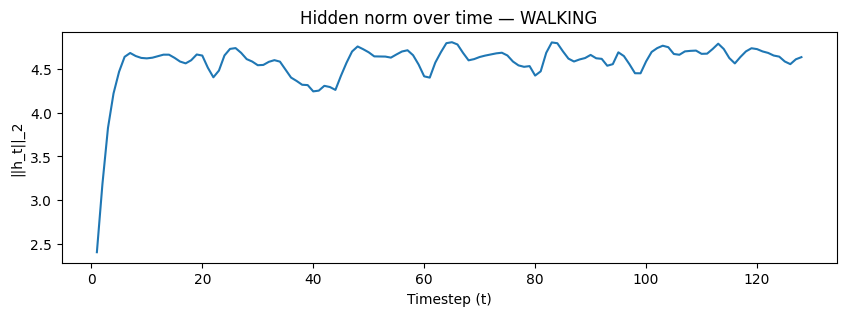

In [14]:
# Visualize a contrasting dynamic class (WALKING = 0) from the same batch

target_label_walk = 0
idx_walk = first_index_of_label(yb, target_label_walk)
if idx_walk is not None:
    hidden_seq_walk = out_seq[idx_walk].cpu().numpy()
    topk_dims_walk = pick_topk_dims_by_variance(hidden_seq_walk, k=3)

    plot_hidden_dims_over_time(
        hidden_seq_walk, topk_dims_walk,
        title=f"Hidden dimensions (top-variance) — {ACTIVITY_MAP[target_label_walk]}"
    )

    plot_hidden_norm_over_time(
        hidden_seq_walk,
        title=f"Hidden norm over time — {ACTIVITY_MAP[target_label_walk]}"
    )
else:
    print("No WALKING example found in this batch; re-run the cell to sample another batch.")


**Reflection**

- **Static vs Dynamic patterns:**  
  For **SITTING**, hidden dimensions often **stabilize** quickly and stay near constant values.  
  For **WALKING**, some hidden dimensions show **oscillations** over time, reflecting periodic motion.

- **Different dims, different roles:**  
  Each hidden neuron (dimension) can specialize in distinct temporal cues; that’s why we select **top-variance** dims to see the most informative activity.

- **Hidden norm as a summary:**  
  The curve of $\lVert h_t \rVert_2$ summarizes how “active” the hidden representation is. Stable norms suggest steady internal state; oscillations or drifts indicate evolving representations.

These views help us interpret **what the RNN is tracking** as the sequence unfolds, and they set us up for the next step: **comparing many sequences in a reduced 2D space (PCA/t-SNE)** to see global structure across classes.

**How to interpret these hidden state plots**

Each curve in the plot corresponds to **one hidden neuron** (or hidden dimension) inside the RNN.  

- At every timestep $t$, the RNN produces a hidden state vector:
  $$
  h_t = [h_t^{(1)}, h_t^{(2)}, \dots, h_t^{(H)}]
  $$
  where $H=32$ in our case.  

- So $h_t^{(j)}$ is the activation of the **$j$-th hidden neuron** at time $t$.  
  Across the sequence (128 timesteps), each neuron produces a **time-series trace**:
  $$
  h_1^{(j)}, h_2^{(j)}, \dots, h_{128}^{(j)}.
  $$

That’s what we’re plotting: the “firing pattern” of selected hidden neurons as the activity unfolds.  

👉 Notice how different neurons behave differently:
- Some stay flat (stable memory).  
- Some flip from negative to positive (switch-like response).  
- Some oscillate (capturing periodic motion).  

Together, all 32 neurons form a **high-dimensional trajectory** that summarizes the input sequence.  
The final hidden state $h_{128}$ is then used by the classifier to decide the activity label.

------------------------------------------------------------------------------

**General Intuitive Interpretation Channels Across Activities**

To connect hidden states back to raw signals, let’s recall how the **3 representative channels** (body accelerometer, total accelerometer, gyroscope) typically look for each of the **6 activities**:

- **Walking** → All channels oscillate around 0, reflecting rhythmic steps.  
- **Walking Upstairs** → Similar oscillations, but with added bursts of acceleration (extra effort against gravity).  
- **Walking Downstairs** → Oscillations again, but often sharper impacts on landing phases.  
- **Sitting** → One channel stays flat (stationary axis), while others gradually decline toward 0.  
- **Standing** → Almost all channels flat, showing very little movement across axes.  
- **Laying** → Channels are flat but with a **different baseline orientation**, since gravity affects axes differently when lying down.

**Intuitive Visual Patterns for Recognition**

These differences form the **visual signatures** of activities:

- **Dynamic activities** (walking, upstairs, downstairs) produce **cyclical wave-like patterns** across channels.  
- **Static activities** (sitting, standing, laying) produce **flat or slowly stabilizing traces**, with laying distinguishable by its unique baseline.  

When we map these sequences into hidden states, we expect the RNN to capture:  
- **Oscillation vs. stillness** as the primary separator.  
- **Subtle variations** (upstairs vs. downstairs) as secondary distinctions.  

This intuition helps us interpret why certain activities cluster together in hidden state space, while others separate cleanly.

---

# **Dimensionality Reduction: PCA / t-SNE on Hidden States**

**Theory**

- Our RNN hidden states live in a **32-dimensional space** (since `hidden_size = 32`).  
- Humans can’t visualize 32D directly, so we use **dimensionality reduction**:
  - **PCA (Principal Component Analysis):**
    - Linear method.
    - Projects data into directions of maximum variance.
    - Fast and interpretable.
  - **t-SNE (t-distributed Stochastic Neighbor Embedding):**
    - Nonlinear method.
    - Preserves local structure (points close in high-dim remain close in 2D).
    - Slower, but can reveal clusters more clearly.

- Why do this?  
  To check whether **hidden states separate activities**:  
  - Do WALKING samples cluster together?  
  - Do SITTING samples stay distinct?  
  - Or do some activities overlap?

In [16]:
# Collect hidden states from one batch
xb, yb = next(iter(test_loader))  # xb: (B,128,9)
with torch.no_grad():
    logits, out_seq, h_n = model(xb)  # out_seq: (B,128,H)

B, T, H = out_seq.shape
hidden_flat = out_seq.reshape(B*T, H).cpu().numpy()  # (B*T, H)
labels_rep = np.repeat(yb.cpu().numpy(), T)         # repeat each label 128 times

print("Hidden states shape for PCA/TSNE:", hidden_flat.shape)

Hidden states shape for PCA/TSNE: (12288, 32)


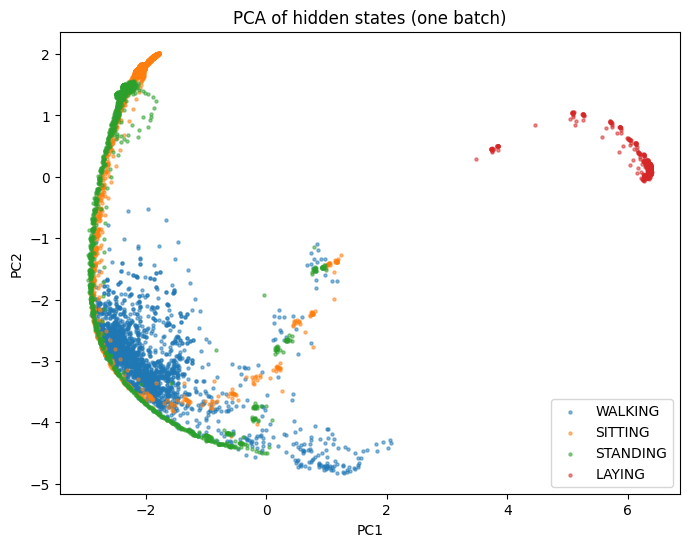

In [17]:
pca = PCA(n_components=2)
hidden_pca = pca.fit_transform(hidden_flat)

plt.figure(figsize=(8,6))
for label in np.unique(labels_rep):
    idxs = labels_rep == label
    plt.scatter(hidden_pca[idxs,0], hidden_pca[idxs,1],
                s=5, alpha=0.5, label=ACTIVITY_MAP[label])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of hidden states (one batch)")
plt.legend()
plt.show()

**Understanding PCA Intuitively**

We used **PCA (Principal Component Analysis)** to reduce our hidden states (32-dimensional vectors) down to **2D points**.  
But how do we go from 32 numbers to just 2?

**Step-by-step intuition**

1. **Hidden states in 32D:**  
   - Each hidden state $h_t \in \mathbb{R}^{32}$ is like a vector with 32 coordinates.  
   - We have thousands of such vectors (from 96 sequences × 128 timesteps each).  

2. **Find directions of maximum variance:**  
   - PCA searches for new axes (directions) that capture the **most variation** in the data.  
   - The **first principal component (PC1)** = direction where the data varies the most.  
   - The **second principal component (PC2)** = direction of the next-most variation, orthogonal to PC1.

3. **Project onto 2D:**  
   - Each 32D hidden vector is projected onto these two new axes (PC1 and PC2).  
   - Now every hidden state can be represented as just two numbers:  
     $$
     \text{Hidden state} \; h_t \;\to\; (PC1\_score, \; PC2\_score).
     $$

**Analogy**

Imagine taking a **shadow of a 3D object** onto a 2D wall:  
- You lose one dimension, but the shadow still shows the **main structure**.  
- PCA works the same way: it chooses the “best wall” (projection) that preserves as much information as possible.

**What to take away**

- Each dot = one hidden state $h_t$ from our RNN.  
- Dots with the same activity label (color) may cluster together if the hidden states encode that activity consistently.  
- Unlike t-SNE, PCA uses **linear projections**, so it may miss some nonlinear structure.  
- But PCA is fast, deterministic, and gives interpretable axes (variance explained by PC1 and PC2).

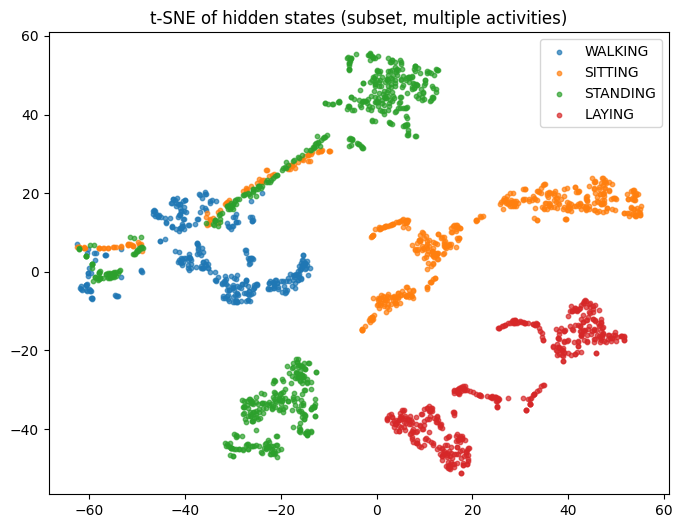

In [18]:
hidden_all = out_seq.reshape(-1, H)        # shape (B*T, H)
labels_all = yb.repeat_interleave(T)       # shape (B*T,)

# Subsample for t-SNE (because it’s slow)
n_samples = 2000
idx = np.random.choice(hidden_all.shape[0], n_samples, replace=False)
hidden_subset = hidden_all[idx]
labels_subset = labels_all[idx]

# Apply t-SNE
tsne = TSNE(n_components=2, init="random", learning_rate="auto", random_state=42)
hidden_2d = tsne.fit_transform(hidden_subset)

# Plot with colors by label
plt.figure(figsize=(8,6))
for lbl in np.unique(labels_subset):
    mask = labels_subset == lbl
    plt.scatter(hidden_2d[mask, 0], hidden_2d[mask, 1], s=10, alpha=0.7, label=ACTIVITY_MAP[int(lbl)])
plt.title("t-SNE of hidden states (subset, multiple activities)")
plt.legend()
plt.show()

**Understanding t-SNE Intuitively**

We used **t-SNE** to reduce our hidden states (32-dimensional vectors) down to **2D points** for visualization.  
But what do these dots really mean?

**Step-by-step intuition**

1. **High-dimensional neighbors (32D):**  
   - Each hidden state $h_t \in \mathbb{R}^{32}$ is a point in 32D space.  
   - t-SNE looks at pairs of points and asks: *“How close are they?”*  
   - It converts these distances into probabilities (closer = higher probability of being neighbors).

2. **Create a 2D world:**  
   - All points are placed in a 2D plane.  
   - Again, we define neighbor probabilities, but this time using a different formula (Student-t distribution, which spreads points out more).

3. **Match the two worlds:**  
   - The algorithm moves the 2D points around so that:  
     - If two hidden states were close in 32D, they end up close in 2D.  
     - If they were far apart in 32D, they don’t collapse together in 2D.  
   - This is done by minimizing a mismatch (called KL-divergence) between the two sets of probabilities.

**Analogy**

Think of it like **flattening a crumpled paper**:

- In 3D (the crumpled ball), two ink dots may be neighbors even if their x/y coordinates look far apart.  
- When we flatten the paper into 2D, we try to keep those neighbor dots still close to each other.  
- We don’t care about the *exact* axes — only about **who stays close and who separates**.

**What to take away**

- Each dot = one hidden state $h_t$ from our RNN.  
- Clusters in 2D suggest the RNN has learned to group certain activities together.  
- The axes (t-SNE dim 1, t-SNE dim 2) **don’t carry meaning** — what matters is the **proximity and clustering**.

**Why did we do this clustering?**

By reducing the 32-dimensional hidden states into 2D, we can **peek inside the RNN’s memory**.  
Instead of treating the model as a black box, these plots show how hidden states arrange themselves:

- If states for the same activity cluster together, it means the RNN has learned an **internal representation** that separates that activity from others.  
- If clusters overlap, it signals **confusion**: the RNN’s hidden space does not clearly separate those activities (e.g., SITTING vs. STANDING).  
- Different reduction methods (PCA, t-SNE) give us complementary views — one linear, one nonlinear — helping us see both the **broad structure** and the **fine details**.

👉 The intuition: these visualizations tell us *how well the RNN is encoding activities in its hidden space*. They reveal **strengths (clear clusters)** and **weaknesses (overlaps)**, guiding us toward improvements like deeper models, LSTMs/GRUs, or better feature engineering.

---

# **Temporal Trajectories in 2D**

**Theory — Hidden states as trajectories**

So far, we have seen hidden states as *points* in high-dimensional space, clustered via PCA or t-SNE.  
But remember: an RNN produces **a sequence of hidden states**  
$$
h_1, h_2, \dots, h_{128}, \quad h_t \in \mathbb{R}^{32}.
$$  

That means each input sequence traces out a **path (trajectory)** in hidden space.  
- For **dynamic activities** (like WALKING), we expect the trajectory to **oscillate** or wander, reflecting rhythmic motion.  
- For **static activities** (like SITTING), the trajectory may be **stable and compact**, since little is changing over time.

By projecting these high-dimensional vectors into **2D PCA space**, we can literally *see* how the RNN’s memory moves as it processes each timestep.


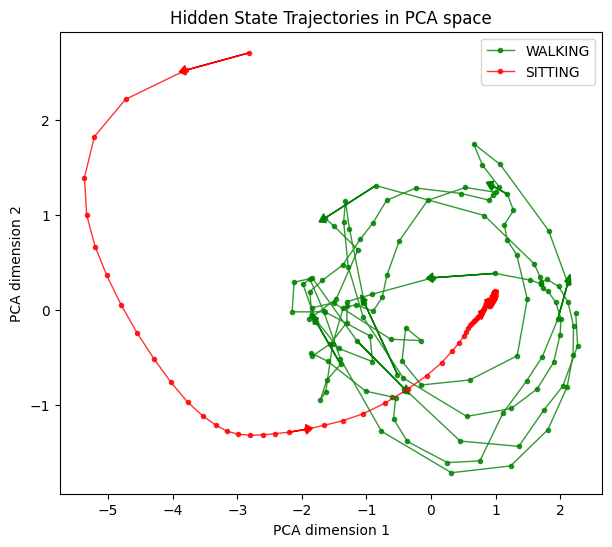

In [19]:
def plot_trajectory(hidden_seq, label, color="blue"):
    """
    hidden_seq: (T, H) numpy array of hidden states
    label: activity string
    """
    # PCA to 2D
    pca = PCA(n_components=2)
    hidden_2d = pca.fit_transform(hidden_seq)  # (T, 2)

    # Plot trajectory with arrows
    plt.plot(hidden_2d[:,0], hidden_2d[:,1], marker="o", markersize=3,
             linewidth=1, color=color, alpha=0.8, label=label)

    # Add arrows for direction (every ~20 timesteps)
    for i in range(0, len(hidden_2d), 20):
        plt.arrow(hidden_2d[i,0], hidden_2d[i,1],
                  hidden_2d[i+1,0]-hidden_2d[i,0],
                  hidden_2d[i+1,1]-hidden_2d[i,1],
                  head_width=0.1, head_length=0.1, fc=color, ec=color)

    return hidden_2d

# --- Pick one WALKING and one SITTING sequence ---
xb, yb = next(iter(test_loader))   # (B,128,9), (B,)
model.eval()
with torch.no_grad():
    logits, out_seq, h_n = model(xb)  # out_seq: (B,128,H)

# Find indices
idx_walk = first_index_of_label(yb, 0)  # WALKING
idx_sit  = first_index_of_label(yb, 3)  # SITTING

plt.figure(figsize=(7,6))

if idx_walk is not None:
    hidden_walk = out_seq[idx_walk].cpu().numpy()
    plot_trajectory(hidden_walk, "WALKING", color="green")

if idx_sit is not None:
    hidden_sit = out_seq[idx_sit].cpu().numpy()
    plot_trajectory(hidden_sit, "SITTING", color="red")

plt.xlabel("PCA dimension 1")
plt.ylabel("PCA dimension 2")
plt.title("Hidden State Trajectories in PCA space")
plt.legend()
plt.show()